# Getting Started with DNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The IMDB Dataset

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [3]:
print(f"Training entries: {len(train_data)}, labels: {len(train_labels)}")
print(f"Test entries: {len(test_data)}, labels: {len(test_labels)}")
print(f"Train data example (first sequence): {train_data[0]}")
print(f"Train label example (first label): {train_labels[0]}")

Training entries: 25000, labels: 25000
Test entries: 25000, labels: 25000
Train data example (first sequence): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 

## Preparing the Data

In [4]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0  # set specific indices of results[i] to 1s
    return results


x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

## Network Architecture

In [5]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Input(shape=(10000,)))
network.add(layers.Dense(16, activation="relu"))
network.add(layers.Dense(16, activation="relu"))
network.add(layers.Dense(1, activation="sigmoid"))

## Network Training

In [6]:
network.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

## Validation

In [7]:
VAL_SIZE = 10000

x_val = x_test[:VAL_SIZE]
y_val = y_test[:VAL_SIZE]

x_test = x_test[VAL_SIZE:]
y_test = y_test[VAL_SIZE:]

In [8]:
print(f"Validation entries: {len(x_val)}, labels: {len(y_val)}")
print(f"Test entries: {len(x_test)}, labels: {len(y_test)}")

Validation entries: 10000, labels: 10000
Test entries: 15000, labels: 15000


In [9]:
history = network.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8159 - loss: 0.4696 - val_accuracy: 0.8590 - val_loss: 0.3718
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8159 - loss: 0.4696 - val_accuracy: 0.8590 - val_loss: 0.3718
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9022 - loss: 0.2820 - val_accuracy: 0.8826 - val_loss: 0.3002
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9022 - loss: 0.2820 - val_accuracy: 0.8826 - val_loss: 0.3002
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9217 - loss: 0.2194 - val_accuracy: 0.8835 - val_loss: 0.2895
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9217 - loss: 0.2194 - val_accuracy: 0.8835 - val_loss: 0.2895
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9332 - loss: 0.1864 - val_accuracy: 0.8787 - val_loss: 0.3010
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9332 - loss: 0.1864 - val_accuracy: 0.8787 - val_los

In [10]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


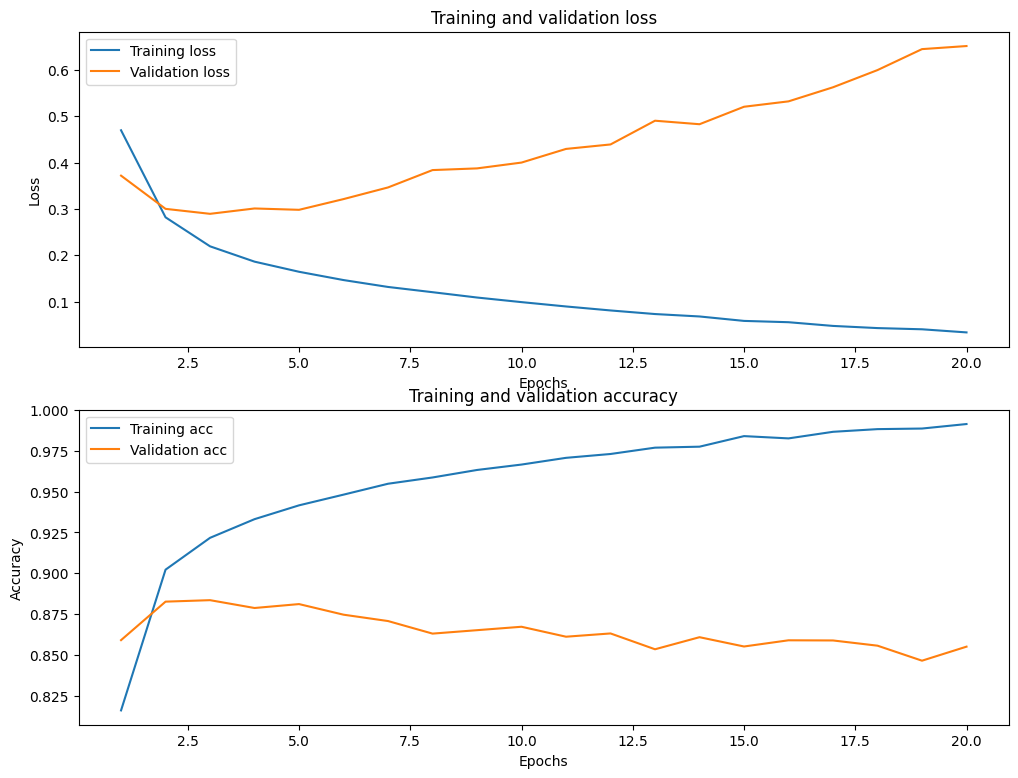

In [11]:
epochs = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 9))

plt.subplot(2, 1, 1)
plt.plot(epochs, history_dict["loss"], label="Training loss")
plt.plot(epochs, history_dict["val_loss"], label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, history_dict["accuracy"], label="Training acc")
plt.plot(epochs, history_dict["val_accuracy"], label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [12]:
results = network.evaluate(x_test, y_test)
print(f"Test loss: {results[0]}, Test accuracy: {results[1]}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8569 - loss: 0.6311
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8569 - loss: 0.6311
Test loss: 0.6310968995094299, Test accuracy: 0.8568666577339172
Test loss: 0.6310968995094299, Test accuracy: 0.8568666577339172


## Part 2 Hyperparameters [[lab1b](https://mdig.agh.edu.pl/dokuwiki/doku.php?id=teaching:data_science:dnn:lab1b#part_2_hyperparameters)]

In [13]:
import tensorflow as tf


class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("accuracy") > 0.9:
            print("\nReached 90% accuracy so cancelling training!")
            self.model.stop_training = True

In [14]:
callbacks = myCallback()
 
network.fit(x_train, y_train, epochs=10, callbacks=[callbacks])

Epoch 1/10
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9858 - loss: 0.0424
Reached 90% accuracy so cancelling training!
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0553

Reached 90% accuracy so cancelling training!
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0553


## Optimisation algorithms from sklearn

## Optimisation algorithms from Keras (optional)

In [15]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier


def create_model():
    network = models.Sequential()
    network.add(layers.Input(shape=(10000,)))
    network.add(layers.Dense(16, activation="relu"))
    network.add(layers.Dense(16, activation="relu"))
    network.add(layers.Dense(1, activation="sigmoid"))

    network.compile(
        optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"]
    )

    return network


model = KerasClassifier(model=create_model)

par1_batch = [32, 64]
par2_epoch = [3, 5]

param_grid = dict(batch_size=par1_batch, epochs=par2_epoch)

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)

grid_results = grid.fit(x_train, y_train)

print("Best: %f using %s" % (grid_results.best_score_, grid_results.best_params_))

Epoch 1/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8573 - loss: 0.3377
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8573 - loss: 0.3377
Epoch 2/3
Epoch 2/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9235 - loss: 0.2033
Epoch 3/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9235 - loss: 0.2033
Epoch 3/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9401 - loss: 0.1613
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9401 - loss: 0.1613
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step
Epoch 1/3
Epoch 1/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8583 - loss: 0.3421
Epoch 2/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8583 - loss: 0.3421
Epoch 2/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9226 - loss: 0.2037
Epoch 3/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9226 - loss: 0.2037
Epoch 3/3
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0

In [16]:
def build_model(hp):
    network = models.Sequential()
    network.add(layers.Input(shape=(10000,)))
    hp_units = hp.Int('units', min_value=16, max_value=64, step=16)
    network.add(layers.Dense(units=hp_units, activation='relu'))
    network.add(layers.Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
 
    network.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=hp_learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
 
    return network

In [17]:
import keras_tuner

tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5)
 
tuner.search(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_val, y_val))
best_model = tuner.get_best_models()[0]

Trial 5 Complete [00h 00m 09s]
val_loss: 0.28738847374916077

Best val_loss So Far: 0.2838737368583679
Total elapsed time: 00h 02m 37s


c:\Users\robert\Desktop\paug-agh-2025\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
